# Support Vector Machine (SVM)

Support vector machines (SVMs) are a particularly powerful and flexible class of supervised algorithms for both classification and regression.

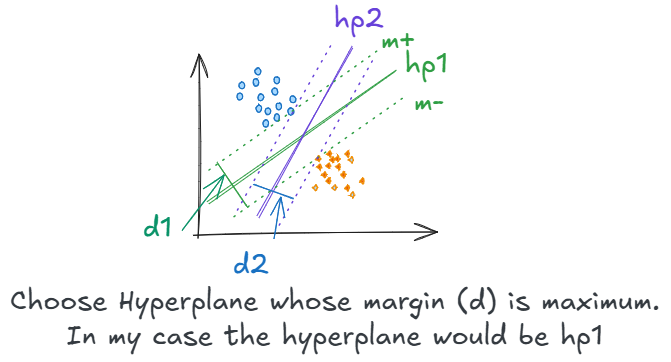

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

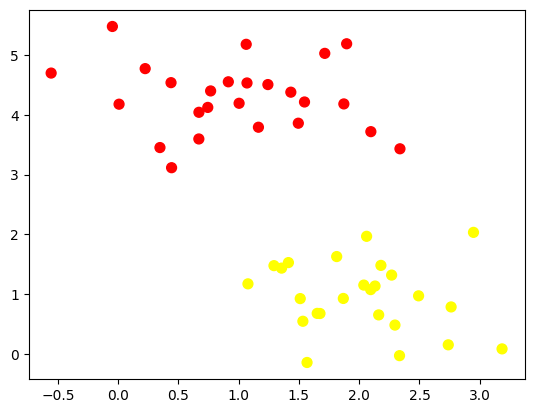

In [2]:
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

A linear SVM classifier would attempt to draw a straight line separating the two datasets, and thereby create a model for classification.
NOte: there is more than one possible dividing line that can perfectly discriminate between the two classes!

We can draw some of them as follows; the following figure shows the result:

In [3]:
def linear_model(x, m=0, b=0):
    return m*x + b

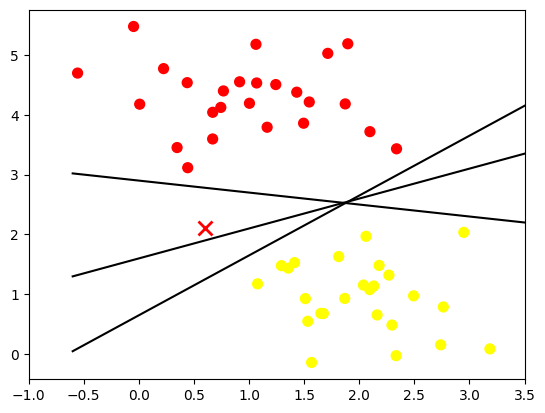

In [4]:
xfit = np.linspace(-0.6, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, linear_model(xfit, m, b), '-k')

plt.xlim(-1, 3.5)
plt.show()

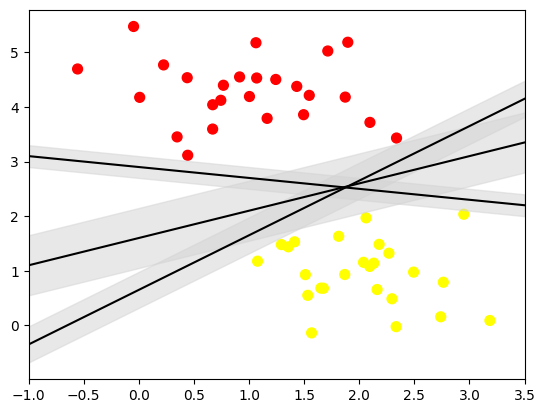

In [7]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = linear_model(xfit, m, b)
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='lightgray', alpha=0.5)

plt.xlim(-1, 3.5)

plt.show()

The line that maximizes this margin is the one we will choose as the optimal model.

### Fitting Support Vector Machine

Let's see the result of an actual fit to this data: we will use Scikit-Learn's support vector classifier (SVC) to train an SVM model on this data. For the time being, we will use a linear kernel and set the C parameter to a very large number

In [8]:
from sklearn.svm import SVC

In [9]:
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

Let's visualize what SVC have done

In [10]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, edgecolors='black',
                   facecolors='none')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

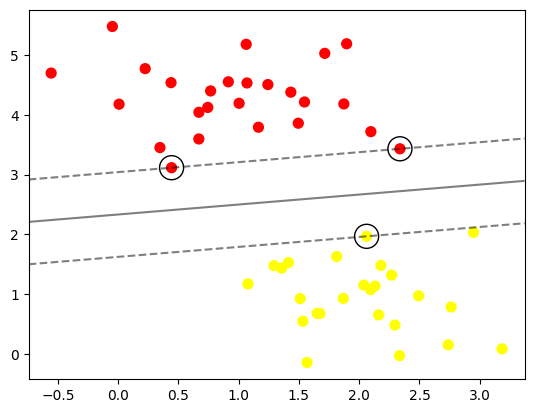

In [11]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)

This is the dividing line that maximizes the margin between the two sets of points. Notice that a few of the training points just touch the margin. These points are known as the support vectors. In Scikit-Learn, the identities of these points are stored in the support_vectors_ attribute of the classifier:

In [12]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

### What if out data is not linearly seperable

In [13]:
from sklearn.datasets import make_circles

In [14]:
X, y = make_circles(100, factor=.1, noise=.1)

In [15]:
clf = SVC(kernel='linear')

In [16]:
clf.fit(X, y)

SVC(kernel='linear')

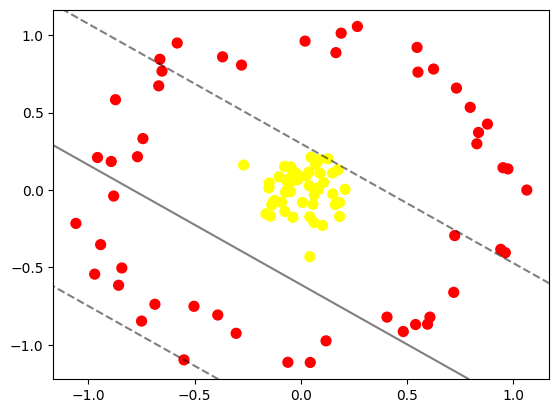

In [17]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

kernels --> linear, rbf, polynomial

In [18]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

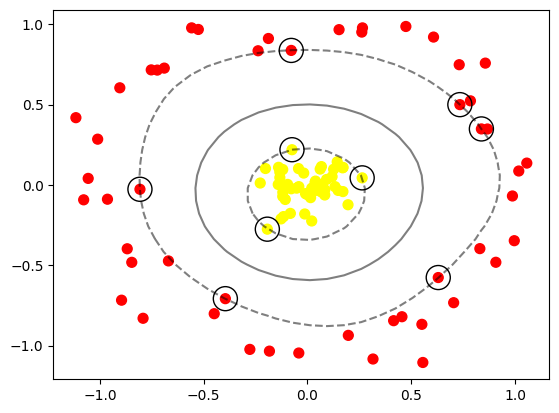

In [17]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')

#### Tuning SVM --> soft margining

What if your data has some amount of overlap? For example, you may have data like this:

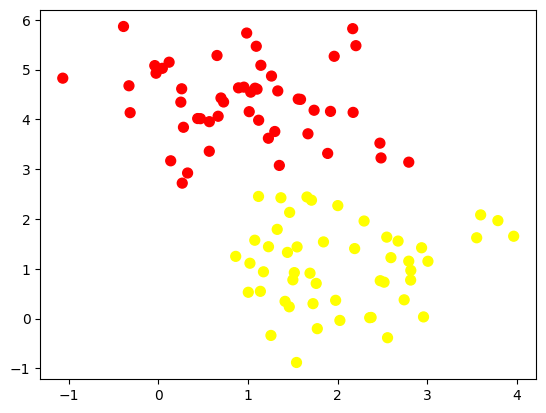

In [22]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.show()

To handle this case, the SVM implementation has a parameter i.e. C that "softens" the margin. The hardness of the margin is controlled by a tuning parameter, most often known as C. For a very large C, the margin is hard, and points cannot lie in it. For a smaller C, the margin is softer and can grow to encompass some points.

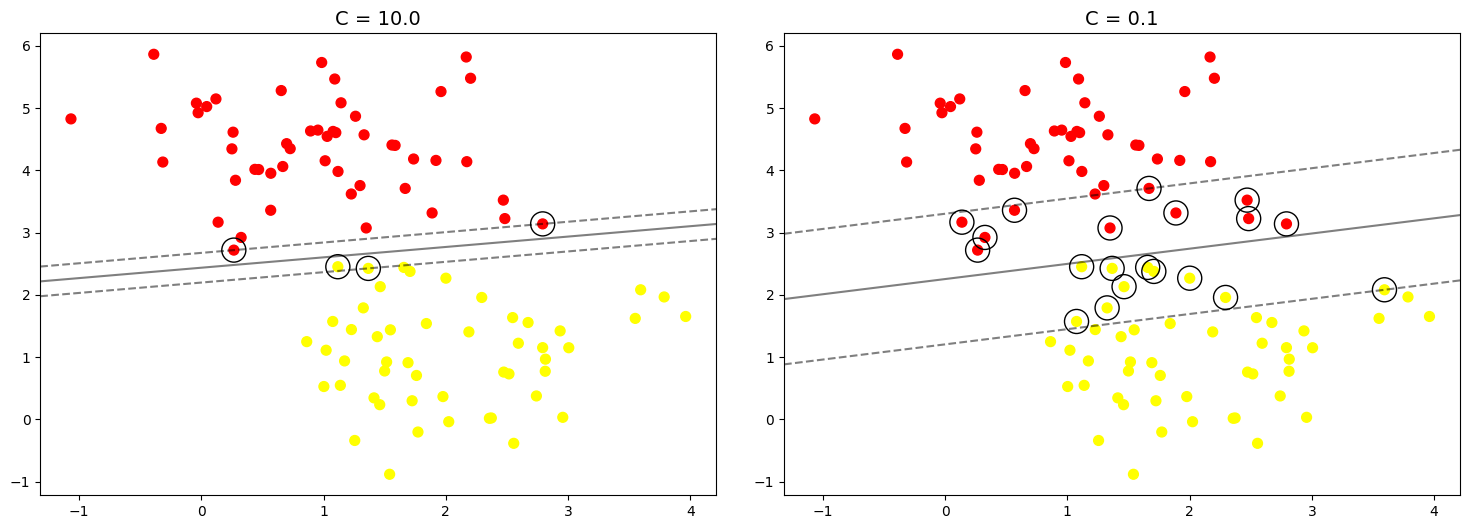

In [23]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none')
    axi.set_title('C = {0:.1f}'.format(C), size=14)

plt.show()

The optimal value of C will depend on your dataset, and you should tune this parameter

In [20]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


### Load Dataset

In [22]:
df = pd.read_csv('Dataset/churn.csv')

In [23]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [25]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [26]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

This Dataset have following columns:  

1. RowNumber  --> No effect on output  
2. CustomerId --> No effect on output  
3. Surname    --> Customer name  
4. CreditScore --> Total credit_score of customer in the bank  [Effect on churn]   
5. Geography   --> Location of customer  [Effect on churn]  
6. Gender      --> Customer's Gender [For exploration of the effect of Gender on churn]  
7. Age         --> Customers age  [Effect on churn]  
8. Tenure      --> No. of years the customer is the client of bank  [Effect on churn]  
9. Balance     --> Customers balance  [Effect on churn]  
10. NumOfProducts --> No. of products customer have purchased through the bank  [Effect on churn]  
11. HasCrCard     --> Customer have credit card - Boolean values 0/1  [Effect on churn]  
12. IsActiveMember  --> Boolean values 0/1  [Effect on churn]  
13. EstimatedSalary --> Estimated salary of customer  [Effect on churn]  
14. Exited          --> whether or not the customer left the bank  

## Exploratory Data Analysis (EDA)

In [27]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [28]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

There is no Null and NAN values in the dataset. So, the dataset is cleaned 

#### Analysing the effect of features on Churn

##### 1. How many customers have left/not left the Bank 

In [29]:
results = df['Exited'].value_counts()

In [30]:
results

Exited
0    7963
1    2037
Name: count, dtype: int64

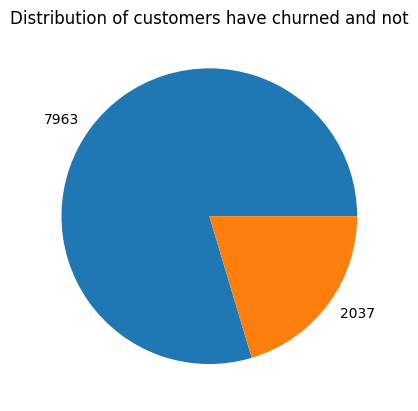

In [31]:
plt.pie(results, labels=results)
plt.title('Distribution of customers have churned and not')
plt.show()

##### 2. Analyzing Numerical features

In [32]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

##### 3. Analyzing Categorical features

In [33]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

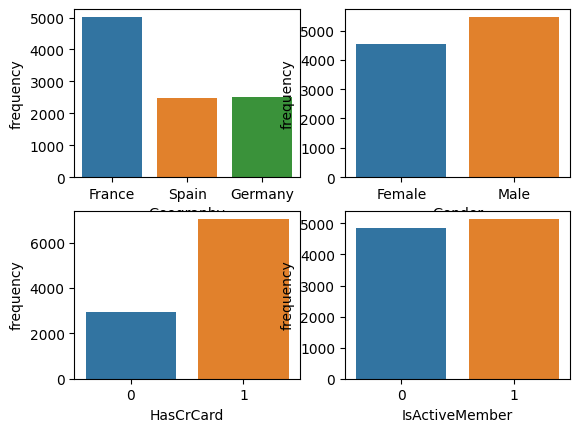

In [34]:
categorical_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

for i, column in enumerate(categorical_features):
    plt.subplot(2,2, i+1)
    sns.countplot(x=df[column])
    #plt.title(column)
    plt.xlabel(column)
    plt.ylabel('frequency')

plt.show()

##### 3. Analyzing Independent features based on output (Exited) column

In [35]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

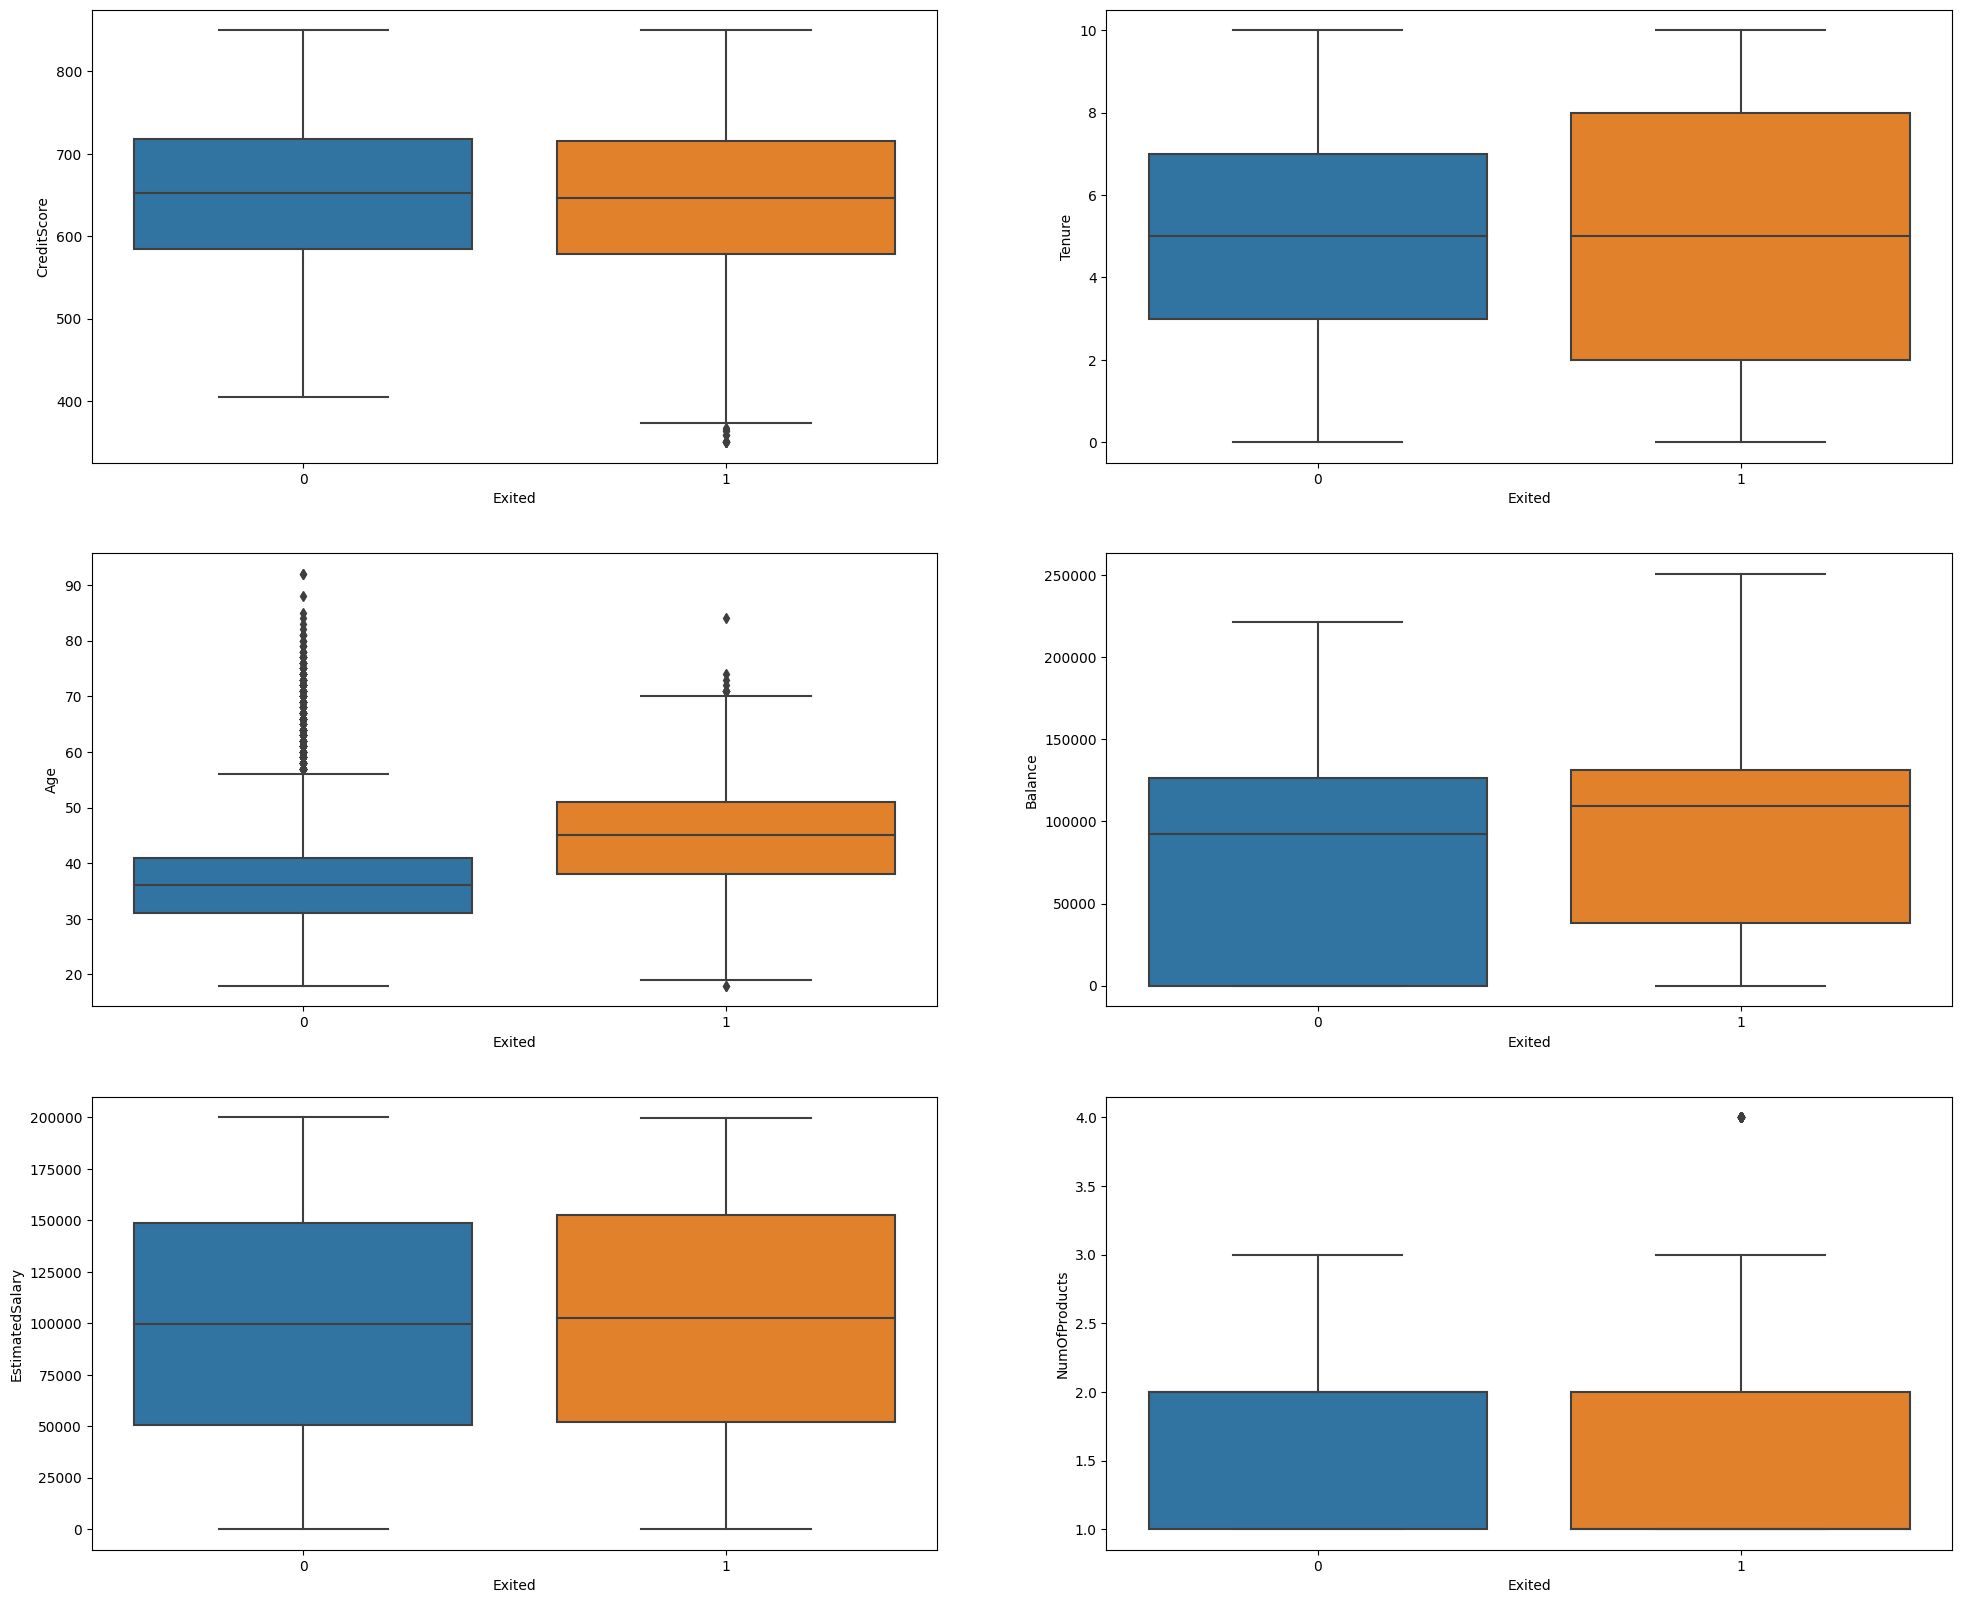

In [36]:
fig, ax = plt.subplots(3,2, figsize=(24,20))

# CreditScore
sns.boxplot(data=df, x='Exited', y='CreditScore', ax=ax[0,0])
# Tenure
sns.boxplot(data=df, x='Exited', y='Tenure', ax=ax[0,1])
# Age
sns.boxplot(data=df, x='Exited', y='Age', ax=ax[1,0])
# Balance 
sns.boxplot(data=df, x='Exited', y='Balance', ax=ax[1,1])
# ExtimatedSalary
sns.boxplot(data=df, x='Exited', y='EstimatedSalary', ax=ax[2,0])
# No. of products
sns.boxplot(data=df, x='Exited', y='NumOfProducts', ax=ax[2,1])

plt.show()

##### 4. 

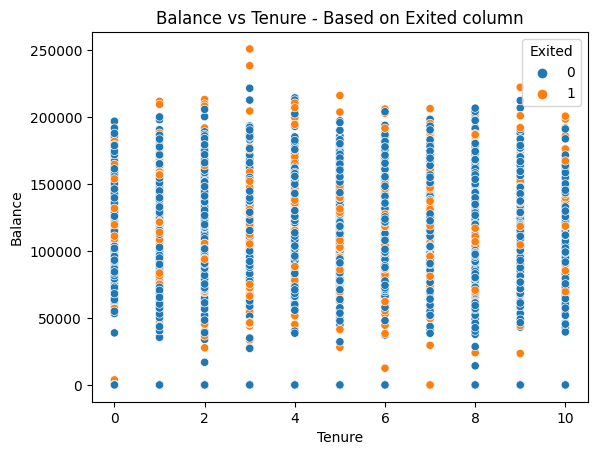

In [37]:
sns.scatterplot(data=df, x='Tenure', y='Balance', hue='Exited')
plt.title('Balance vs Tenure - Based on Exited column')
plt.show()

##### 5. Feature Engineering

In [38]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [39]:
df['CreditUtilization'] = df['Balance']/df['CreditScore']
# Interaction Score
df['InteractionScore'] = df['NumOfProducts'] + df['HasCrCard'] + df['IsActiveMember']
# Balance to Salary Ratio
df['BalanceToSalary'] = df['Balance']/df['EstimatedSalary']

##### 6. Visualizing Heatmap

In [40]:
df_new = df.drop(['Surname', 'RowNumber', 'CustomerId', 'Geography', 'Gender'], axis=1)

In [41]:
df_new

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000
1,608,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677
2,502,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000
4,850,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000
9996,516,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108
9997,709,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000
9998,772,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230


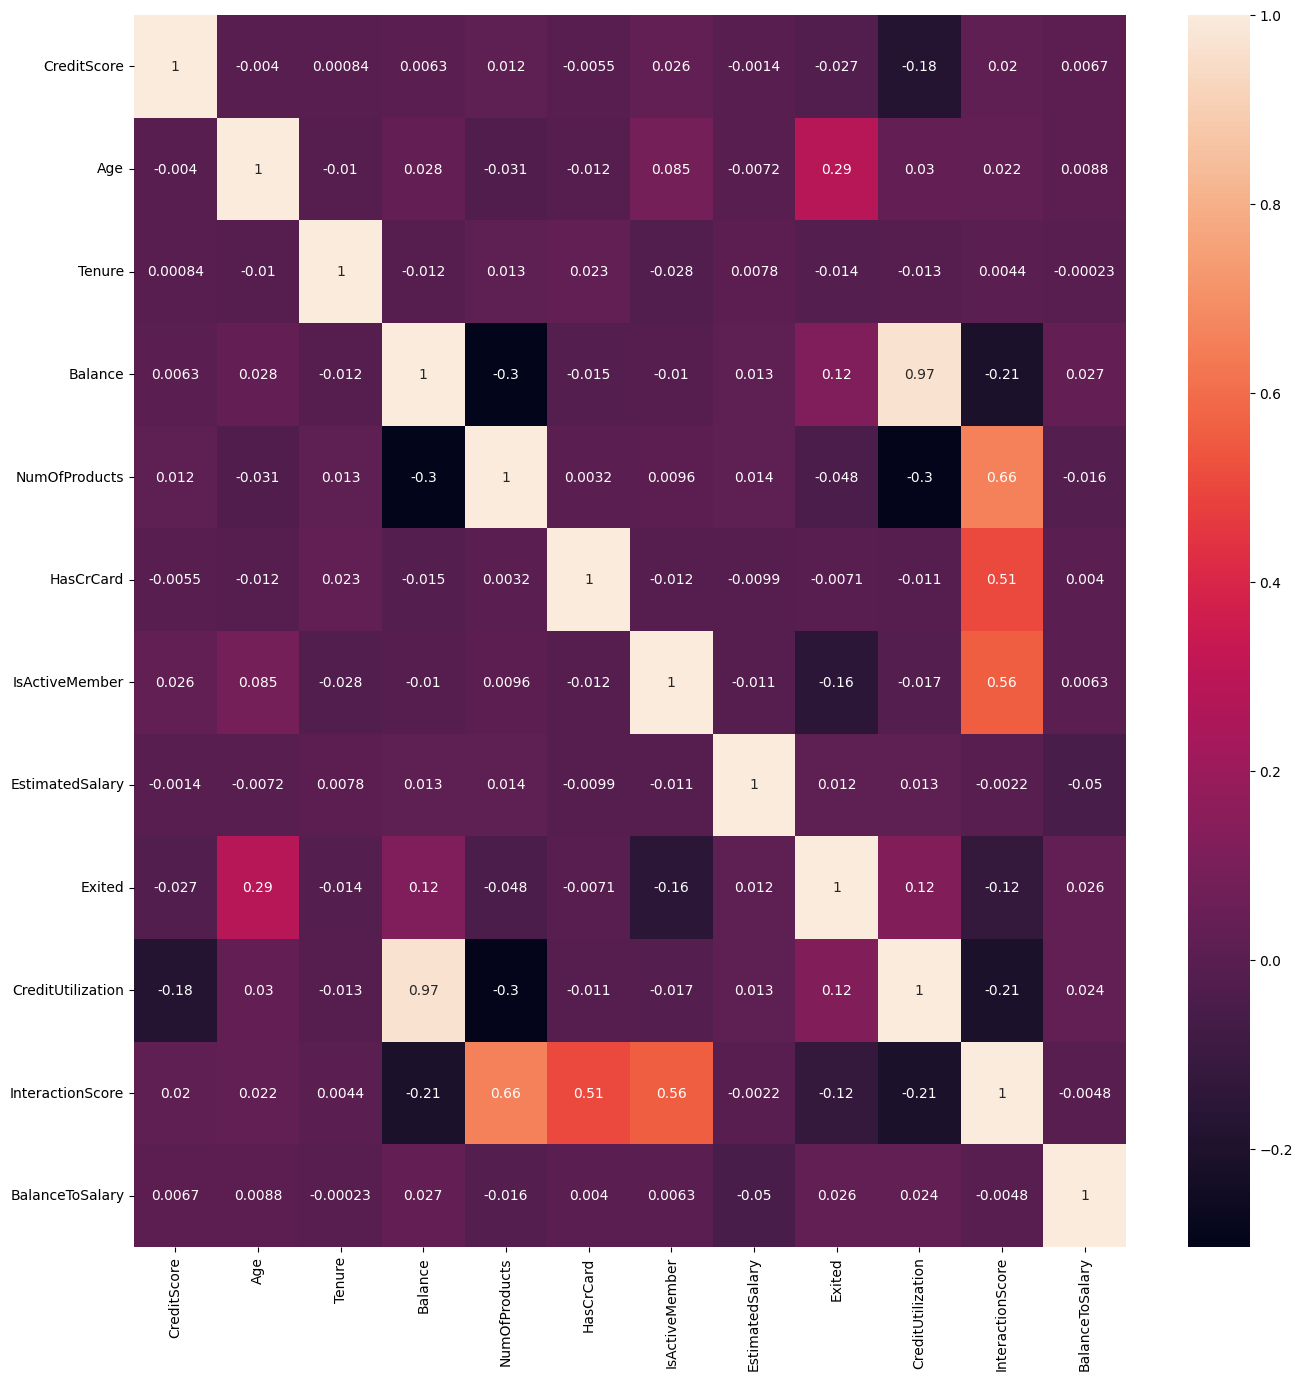

In [42]:
plt.figure(figsize=(16,16))
sns.heatmap(df_new.corr(), annot=True)

plt.show()

In [43]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230


In [44]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

### One-Hot Encoding and Label Encoding

Applying label Encoding to gender column


In [45]:
label_encoder = LabelEncoder()

df['Gender'] = label_encoder.fit_transform(df['Gender'])  # Male =1 , Female=0

In [46]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary
0,619,France,0,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375
3,699,France,0,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230


In [47]:
df['Gender'].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

In [48]:
# Step 4: One-Hot Encode Geography
ohe = OneHotEncoder(sparse_output=False) 

geo_encoded = ohe.fit_transform(df[['Geography']])

In [49]:
geo_encoded

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [50]:
ohe.get_feature_names_out()

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [51]:
geo_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out())

In [52]:
df = df.drop('Geography', axis=1)

In [53]:
# Combine encoded Geography with the rest of the dataset
df = pd.concat([df, geo_df], axis=1)

In [54]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000,1.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108,1.0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000,1.0,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230,0.0,1.0,0.0


##### 7. Seperate dependent and Independent features

In [55]:
df.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'CreditUtilization', 'InteractionScore', 'BalanceToSalary',
       'Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [56]:
X = df.drop(['Exited'], axis=1)
Y = df['Exited']

In [57]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [59]:
svc = SVC(kernel='rbf',  class_weight='balanced')

In [60]:
X_train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,CreditUtilization,InteractionScore,BalanceToSalary,Geography_France,Geography_Germany,Geography_Spain
9069,619,0,32,4,175406.13,2,1,1,172792.43,283.370162,4,1.015126,0.0,0.0,1.0
2603,643,0,34,7,160426.07,1,0,1,188533.11,249.496221,2,0.850917,0.0,1.0,0.0
7738,561,1,33,6,0.00,2,0,0,173680.39,0.000000,2,0.000000,1.0,0.0,0.0
1579,618,1,41,8,37702.79,1,1,1,195775.48,61.007751,3,0.192582,0.0,1.0,0.0
5058,714,1,37,9,148466.93,2,0,1,151280.96,207.936877,3,0.981399,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,768,1,54,8,69712.74,1,1,1,69381.05,90.771797,3,1.004781,1.0,0.0,0.0
5191,682,0,58,1,0.00,1,1,1,706.50,0.000000,3,0.000000,1.0,0.0,0.0
5390,735,0,38,1,0.00,3,0,0,92220.12,0.000000,3,0.000000,1.0,0.0,0.0
860,667,1,43,8,190227.46,1,1,0,97508.04,285.198591,2,1.950890,1.0,0.0,0.0


In [61]:
Y_train

9069    1
2603    0
7738    0
1579    0
5058    0
       ..
5734    0
5191    0
5390    1
860     1
7270    0
Name: Exited, Length: 7000, dtype: int64

In [62]:
svc.fit(X_train, Y_train)

SVC(class_weight='balanced')

In [63]:
y_pred = svc.predict(X_test)

In [65]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.39      0.53      2416
           1       0.23      0.74      0.35       584

    accuracy                           0.46      3000
   macro avg       0.54      0.56      0.44      3000
weighted avg       0.74      0.46      0.50      3000



In [66]:
print(confusion_matrix(Y_test, y_pred))

[[ 933 1483]
 [ 150  434]]


<Axes: >

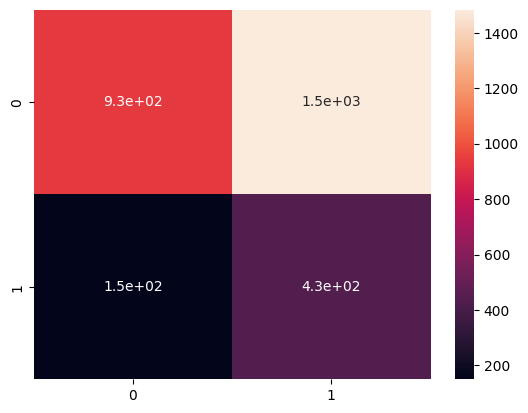

In [68]:
sns.heatmap(confusion_matrix(Y_test, y_pred), annot=True)

In [69]:
print(accuracy_score(Y_test, y_pred))

0.45566666666666666


In [70]:
print(precision_score(Y_test, y_pred))

0.22639540949400105


In [71]:
print(recall_score(Y_test, y_pred))

0.7431506849315068


In [72]:
print(f1_score(Y_test, y_pred))

0.3470611755297881


### Tuning SVM using GridSearchCV

In [73]:
from sklearn.model_selection import GridSearchCV

In [74]:
param_grid = {
    'C': [0.1,1,10,50],
    'gamma': [0.01, 0.1,1],
    'kernel': ['rbf']
}

In [75]:
svm = SVC(class_weight='balanced', probability=True)

grid = GridSearchCV(
    svm, param_grid, scoring='f1'
)

In [76]:
grid.fit(X_train_scaled, Y_train)

GridSearchCV(estimator=SVC(class_weight='balanced', probability=True),
             param_grid={'C': [0.1, 1, 10, 50], 'gamma': [0.01, 0.1, 1],
                         'kernel': ['rbf']},
             scoring='f1')

In [81]:
grid.best_params_

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

In [77]:
best_svm = grid.best_estimator_

In [78]:
y_pred = best_svm.predict(X_test_scaled)


In [79]:
confusion_matrix(Y_test, y_pred)

array([[1936,  480],
       [ 155,  429]], dtype=int64)

In [82]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.80      0.86      2416
           1       0.47      0.73      0.57       584

    accuracy                           0.79      3000
   macro avg       0.70      0.77      0.72      3000
weighted avg       0.84      0.79      0.80      3000



Test data:

Credit Score: 502  
Gender: Female  
Age: 42	  
Tenure: 8  	
Balance: 159660.80  	
Num_preducts: 3	  
Has_creditcard: 1  	
IsActive: 0	  
EstimatedSalary: 113931.57  	
Geography: France  

----------------  
Exited  ---> 1 (churn)  
----------------  

In [83]:
credit_score = int(input('Enter CreditScore: '))  # 596

# I have label encoded Gender
gender = input("Enter Gender")  # Male/Female
gender = label_encoder.transform([gender])[0]

age = int(input('Enter Age')) # 32

Tenure = float(input("Enter Tenure"))  # 3

Balance = float(input("Enter Balance:"))  # 96709.07

Num_products = int(input("Enter Num products: "))  # 2

has_credit_card = int(input("Has credit card (Enter 0/1): ")) # 0

is_active = int(input("Is active (0/1): "))  # 0

Estimated_salary = float(input("Enter Estimated salary: ")) # 41788.37

geography = input("Enter Geography [France, Germany, Spain]")  # Germany
geography = ohe.transform([[geography]])[0]

credit_utilization = Balance/Estimated_salary

interaction_score = Num_products + has_credit_card + is_active

balance_to_salary = Balance/Estimated_salary


inputs = [[credit_score, gender, age, Tenure, Balance, Num_products, has_credit_card, is_active, Estimated_salary, credit_utilization, interaction_score, balance_to_salary, geography[0], geography[1], geography[2]]]

inputs_scaled = scaler.transform(inputs)

inputs_scaled

c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-1.56048763, -1.09823226,  0.29510101,  1.04494014,  1.33186432,
         2.54267727,  0.64598061, -1.03016917,  0.2273116 , -1.17098985,
         1.3944171 , -0.06312282,  0.99828718, -0.57559072, -0.57779016]])

In [84]:
churn = best_svm.predict(inputs_scaled)

print("churn: ", churn)

churn:  [1]


#### Save model, and Encoders and scalard for creating app

In [85]:
import joblib

In [87]:
joblib.dump(label_encoder, 'churn_label_encoder.pkl')
joblib.dump(ohe, 'churn_One_hot_encoder.pkl')
joblib.dump(scaler, 'churn_scala.pkl')
joblib.dump(best_svm,  'churn_SVM_model.pkl')

['churn_SVM_model.pkl']